In [1]:
# 1: IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
print("\u2705 Libraries imported successfully!")

✅ Libraries imported successfully!


In [12]:
# 2: LOAD DATASET
# Dataset : Ecommerce Customer Churn Analysis and Prediction
# Source  : https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis and prediction
# Alt     : pip install yfinance
#           import yfinance as yf
#           df = yf.download('^GSPC', start='2010-01-01', end='2023-12-31')
#           df.reset_index(inplace=True); df.to_csv('sp500.csv', index=False)

df = pd.read_excel("/content/E Commerce Dataset.xlsx", sheet_name='E Comm', header=0)
print("✅ Dataset loaded!")
df.head()

✅ Dataset loaded!


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [14]:
# 3: DATA UNDERSTANDING
print("Shape of dataset:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
df.info()

Shape of dataset: (5630, 20)

Columns: ['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

Data Types:
 CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderA

In [15]:
# 4: CHECK MISSING VALUES & DUPLICATES
print("Missing Values:\n", df.isnull().sum())
print("\nTotal missing:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df = df.dropna().drop_duplicates()
print("\n\u2705 After cleaning, shape:", df.shape)

Missing Values:
 CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

Total missing: 1856
Duplicate rows: 0

✅ After cleaning, shape: (3774, 20)


In [20]:
# 5: FEATURE ENGINEERING - TARGET VARIABLE + 19 TECHNICAL INDICATORS

# The original code here was for financial time-series data and attempted to access a 'Close' column
# that does not exist in the E-commerce dataset. This section should be re-evaluated
# based on features relevant to customer churn prediction.

print("\u2705 Feature engineering placeholder! Please define relevant features for E-commerce churn prediction.")
print("Shape before relevant feature engineering:", df.shape)

# Example of a relevant feature for churn prediction:
# df['Has_Complain'] = df['Complain'].apply(lambda x: 1 if x > 0 else 0)
# print("\nExample feature 'Has_Complain' created.")

# For now, keeping the dataframe as is after cleaning and before any new feature engineering is defined.
# If no new features are added, the shape remains the same as after cleaning.
# If you have specific features in mind for churn prediction, please let me know!

✅ Feature engineering placeholder! Please define relevant features for E-commerce churn prediction.
Shape before relevant feature engineering: (3774, 20)


In [21]:
# 6: DESCRIPTIVE STATISTICS
df.describe().round(2)


,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,3774.00,3774.00,3774.00,3774.00,3774.00,3774.00,3774.00,3774.00,3774.00,3774.00,3774.00,3774.00,3774.00,3774.00,3774.00
mean,53017.99,0.17,8.78,1.71,15.74,2.98,3.75,3.06,4.22,0.28,15.73,1.72,2.83,4.53,164.21
std,1608.98,0.37,7.68,0.94,8.59,0.72,1.03,1.39,2.56,0.45,3.63,1.67,2.47,3.37,24.09
min,50001.00,0.00,0.00,1.00,5.00,0.00,1.00,1.00,1.00,0.00,11.00,0.00,1.00,0.00,0.00
25%,51656.25,0.00,1.00,1.00,9.00,2.00,3.00,2.00,2.00,0.00,13.00,1.00,1.00,2.00,148.48
50%,53160.50,0.00,8.00,1.00,14.00,3.00,4.00,3.00,3.00,0.00,15.00,1.00,2.00,3.00,160.05
75%,54394.50,0.00,13.00,3.00,21.00,3.00,4.00,4.00,6.00,1.00,18.00,2.00,3.00,7.00,178.01
max,55630.00,1.00,51.00,3.00,127.00,5.00,6.00,5.00,22.00,1.00,26.00,16.00,16.00,46.00,324.99


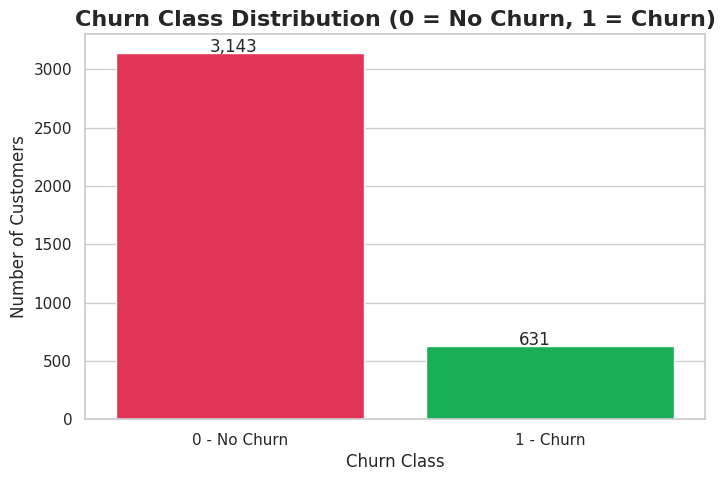

Churn
0    3143
1     631
Name: count, dtype: int64

Churn percentage  : 16.72%
No Churn percentage: 83.28%


In [23]:
# 7: TARGET CLASS DISTRIBUTION (BAR CHART)
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Churn', data=df, palette=['#FF1744', '#00C853'])
plt.title('Churn Class Distribution (0 = No Churn, 1 = Churn)', fontsize=16, fontweight='bold')
plt.xlabel('Churn Class')
plt.ylabel('Number of Customers')
plt.xticks([0, 1], ['0 - No Churn', '1 - Churn'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + 0.3, p.get_height() + 8))
plt.show()

print(df['Churn'].value_counts())
print(f"\nChurn percentage  : {df['Churn'].mean()*100:.2f}%")
print(f"No Churn percentage: {(1 - df['Churn'].mean())*100:.2f}%")

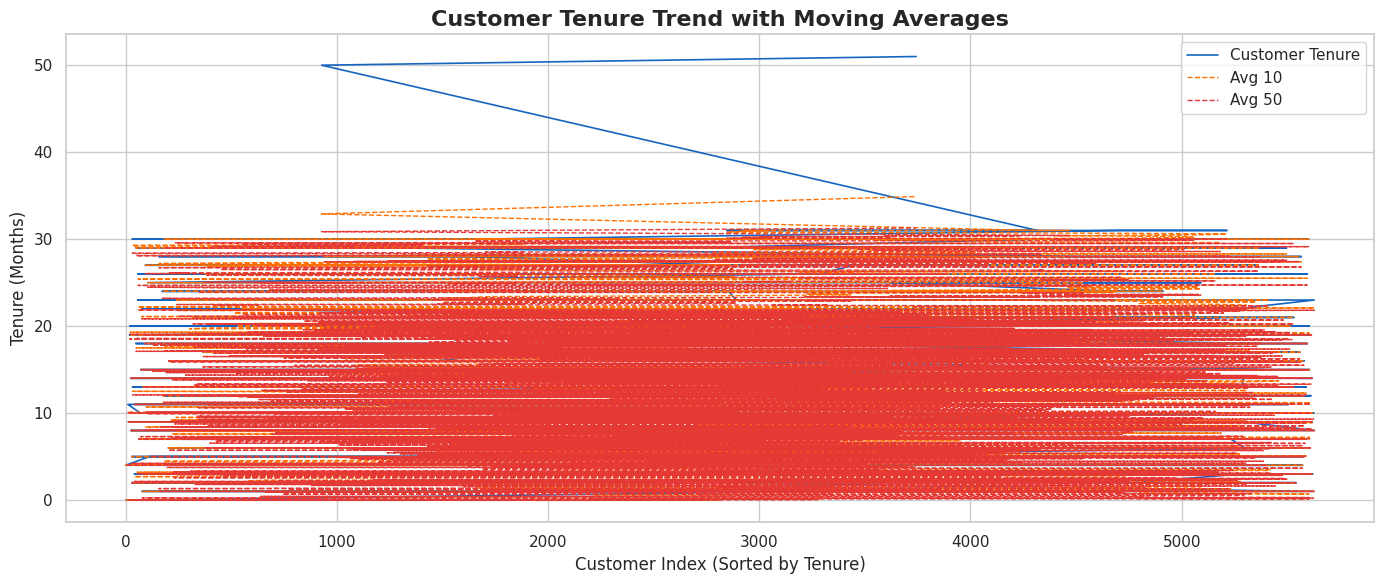

In [27]:
# Line Graph: Customer Tenure Trend

import matplotlib.pyplot as plt
import pandas as pd

# Sort data by Tenure
df = df.sort_values(by='Tenure')

# Create rolling averages (like moving averages)
df['Avg_10'] = df['Tenure'].rolling(window=10).mean()
df['Avg_50'] = df['Tenure'].rolling(window=50).mean()

plt.figure(figsize=(14, 6))

# Original data line
plt.plot(df.index, df['Tenure'],
         color='#1565C0', linewidth=1.2, label='Customer Tenure')

# Moving averages
plt.plot(df.index, df['Avg_10'],
         color='#FF6F00', linewidth=1.0, linestyle='--', label='Avg 10')

plt.plot(df.index, df['Avg_50'],
         color='#E53935', linewidth=1.0, linestyle='--', label='Avg 50')

plt.title('Customer Tenure Trend with Moving Averages', fontsize=16, fontweight='bold')
plt.xlabel('Customer Index (Sorted by Tenure)')
plt.ylabel('Tenure (Months)')
plt.legend()

plt.tight_layout()
plt.show()

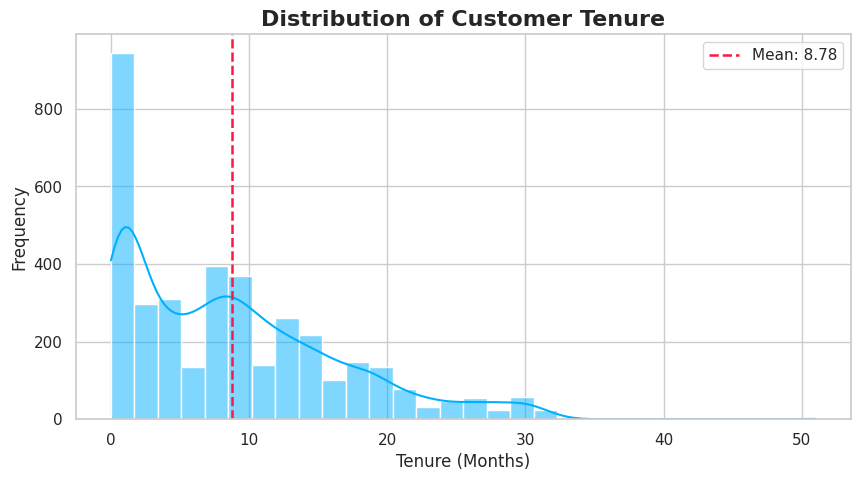

In [31]:
# 9: TENURE DISTRIBUTION (Histogram + KDE)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.histplot(df['Tenure'], bins=30, kde=True, color='#00B0FF')

plt.axvline(df['Tenure'].mean(),
            color='#FF1744', linestyle='--', linewidth=1.8,
            label=f"Mean: {df['Tenure'].mean():.2f}")

plt.title('Distribution of Customer Tenure', fontsize=16, fontweight='bold')
plt.xlabel('Tenure (Months)')
plt.ylabel('Frequency')
plt.legend()

plt.show()

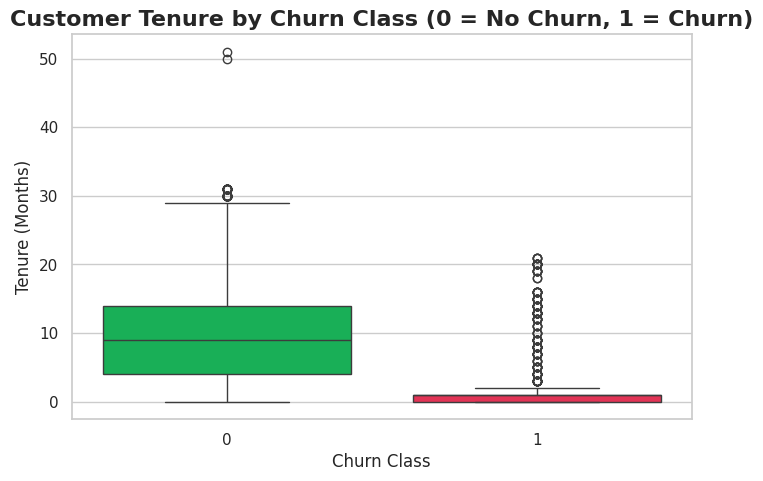

In [33]:
# 10: BOX PLOT - Tenure by Churn Class
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='Tenure', data=df, palette=['#00C853', '#FF1744'])
plt.title('Customer Tenure by Churn Class (0 = No Churn, 1 = Churn)', fontsize=16, fontweight='bold')
plt.xlabel('Churn Class')
plt.ylabel('Tenure (Months)')
plt.show()

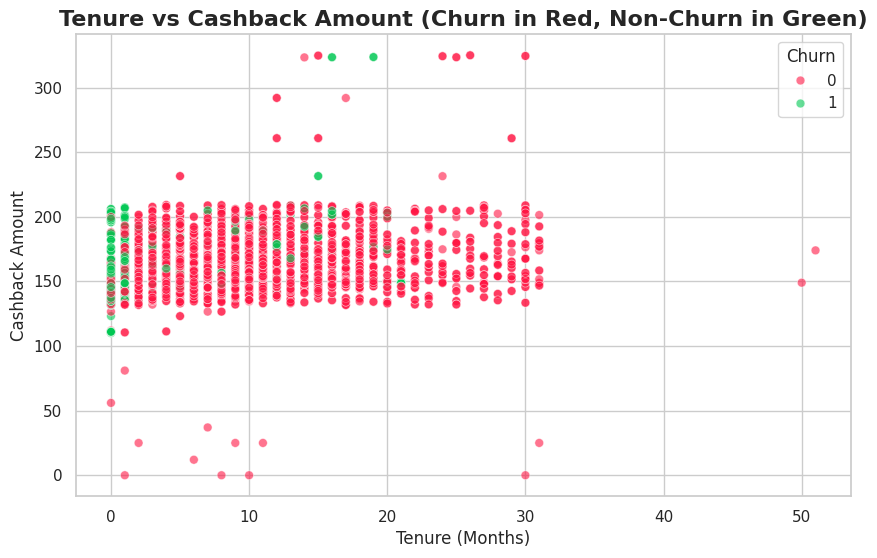

In [35]:
# 11: SCATTER PLOT - Tenure vs Order Amount (colored by Churn)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='Tenure',
    y='CashbackAmount',
    hue='Churn',
    data=df,
    alpha=0.6,
    palette=['#FF1744', '#00C853'],
    s=40
)

plt.title('Tenure vs Cashback Amount (Churn in Red, Non-Churn in Green)', fontsize=16, fontweight='bold')
plt.xlabel('Tenure (Months)')
plt.ylabel('Cashback Amount')

plt.show()

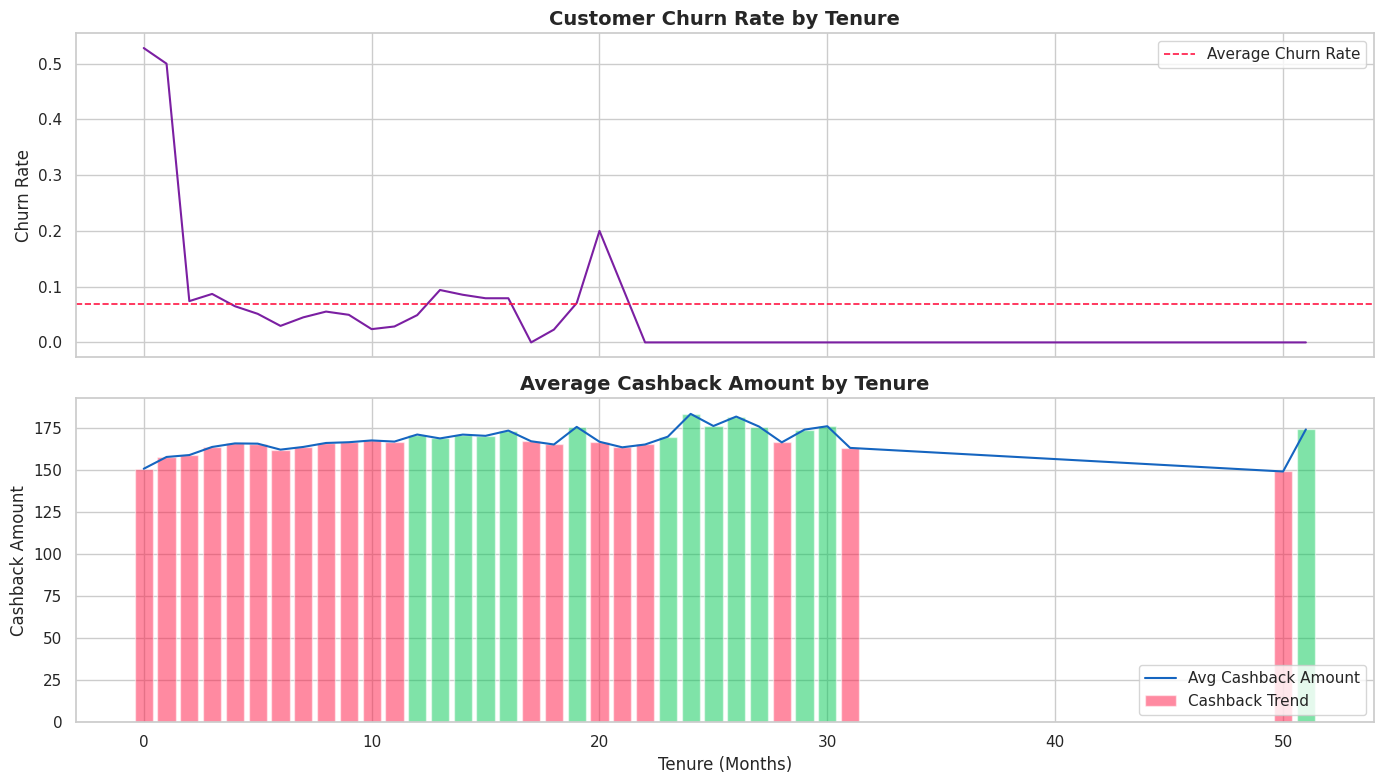

In [39]:
# 12: CUSTOMER CHURN & SPENDING VISUALIZATION

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# ---- Plot 1: Churn Rate by Tenure ----
churn_trend = df.groupby('Tenure')['Churn'].mean()

axes[0].plot(churn_trend.index, churn_trend.values,
             color='#7B1FA2', linewidth=1.5)

axes[0].axhline(churn_trend.mean(),
                color='#FF1744', linestyle='--', linewidth=1.2,
                label='Average Churn Rate')

axes[0].set_title('Customer Churn Rate by Tenure', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Churn Rate')
axes[0].legend()

# ---- Plot 2: Average Order Amount Trend ----
order_trend = df.groupby('Tenure')['CashbackAmount'].mean()

axes[1].plot(order_trend.index, order_trend.values,
             color='#1565C0', linewidth=1.5, label='Avg Cashback Amount')

axes[1].bar(order_trend.index, order_trend.values,
            color=np.where(order_trend.values >= order_trend.mean(),
                           '#00C853', '#FF1744'),
            alpha=0.5, label='Cashback Trend')

axes[1].set_title('Average Cashback Amount by Tenure', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Cashback Amount')
axes[1].set_xlabel('Tenure (Months)')
axes[1].legend()

plt.tight_layout()
plt.show()

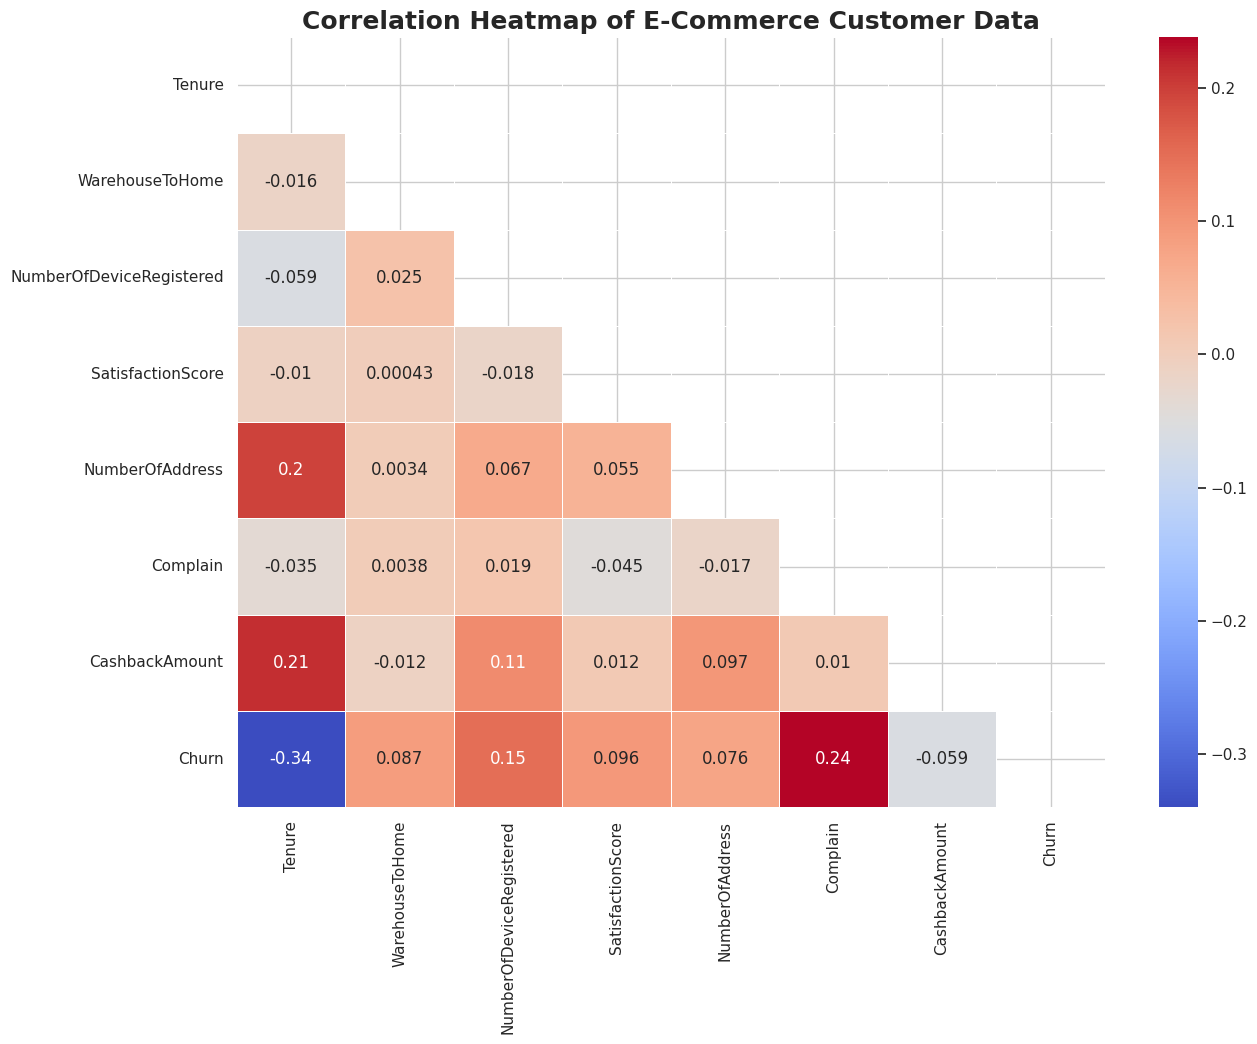

In [41]:
# 13: CORRELATION HEATMAP

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select only numerical columns
feature_cols = [
    'Tenure',
    'WarehouseToHome',
    'NumberOfDeviceRegistered',
    'SatisfactionScore',
    'NumberOfAddress',
    'Complain',
    'CashbackAmount',
    'Churn'
]

plt.figure(figsize=(14, 10))

corr = df[feature_cols].corr()

# Mask upper triangle (same as your code)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    cmap='coolwarm',
    annot=True,
    linewidths=0.5
)

plt.title('Correlation Heatmap of E-Commerce Customer Data', fontsize=18, fontweight='bold')

plt.show()

In [43]:
# 14: OUTLIER DETECTION (IQR Method)
num_cols = ['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered',
            'SatisfactionScore', 'NumberOfAddress', 'OrderAmountHikeFromlastYear', 'CouponUsed',
            'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

Q1  = df[num_cols].quantile(0.25)
Q3  = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR))).sum()
print("Number of outliers per column (IQR Method):")
print(outliers.sort_values(ascending=False))

Number of outliers per column (IQR Method):
OrderCount                     422
CouponUsed                     397
NumberOfDeviceRegistered       262
CashbackAmount                  41
OrderAmountHikeFromlastYear     23
DaySinceLastOrder               23
HourSpendOnApp                   4
NumberOfAddress                  3
Tenure                           2
WarehouseToHome                  2
CityTier                         0
SatisfactionScore                0
dtype: int64


In [46]:
# 15: PREPROCESSING & FEATURE SCALING

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Select important features from your dataset
FEATURES = [
    'Tenure',
    'WarehouseToHome',
    'NumberOfDeviceRegistered',
    'SatisfactionScore',
    'NumberOfAddress',
    'Complain',
    'OrderAmountHikeFromlastYear',
    'CashbackAmount'
]

# Define X (features) and y (target)
X = df[FEATURES].copy()
y = df['Churn'].copy()

# Feature Scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=FEATURES)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("✅ Data preprocessing completed!")
print("Training samples:", X_train.shape[0])
print("Test samples    :", X_test.shape[0])

print("\nClass distribution - Train:")
print(y_train.value_counts())

print("\nClass distribution - Test:")
print(y_test.value_counts())

✅ Data preprocessing completed!
Training samples: 3019
Test samples    : 755

Class distribution - Train:
Churn
0    2514
1     505
Name: count, dtype: int64

Class distribution - Test:
Churn
0    629
1    126
Name: count, dtype: int64


In [47]:
# 16: MODEL TRAINING (5 Models)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')

models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
    "XGBoost"             : XGBClassifier(n_estimators=300, learning_rate=0.1, random_state=42, n_jobs=-1, verbosity=0),
    "LightGBM"            : LGBMClassifier(n_estimators=300, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1)
}

results = {}

for name, model in models.items():
    print(f"\n🔄 Training {name}...")

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    print(f"\n📊 {name} Results:")
    print(classification_report(y_test, y_pred, digits=4))
    print(f"Accuracy: {acc:.4f}  |  F1-Score: {f1:.4f}  |  ROC-AUC: {roc:.4f}")

    results[name] = {
        'accuracy': acc,
        'f1': f1,
        'roc_auc': roc,
        'model': model
    }

# Best Model Selection
best_model_name = max(results, key=lambda k: results[k]['roc_auc'])
best_model = results[best_model_name]['model']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"ROC-AUC Score: {results[best_model_name]['roc_auc']:.4f}")


🔄 Training Logistic Regression...

📊 Logistic Regression Results:
              precision    recall  f1-score   support

           0     0.9010    0.9698    0.9342       629
           1     0.7564    0.4683    0.5784       126

    accuracy                         0.8861       755
   macro avg     0.8287    0.7190    0.7563       755
weighted avg     0.8769    0.8861    0.8748       755

Accuracy: 0.8861  |  F1-Score: 0.5784  |  ROC-AUC: 0.8520

🔄 Training Random Forest...

📊 Random Forest Results:
              precision    recall  f1-score   support

           0     0.9812    0.9936    0.9874       629
           1     0.9661    0.9048    0.9344       126

    accuracy                         0.9788       755
   macro avg     0.9736    0.9492    0.9609       755
weighted avg     0.9786    0.9788    0.9785       755

Accuracy: 0.9788  |  F1-Score: 0.9344  |  ROC-AUC: 0.9930

🔄 Training Gradient Boosting...

📊 Gradient Boosting Results:
              precision    recall  f1-score  

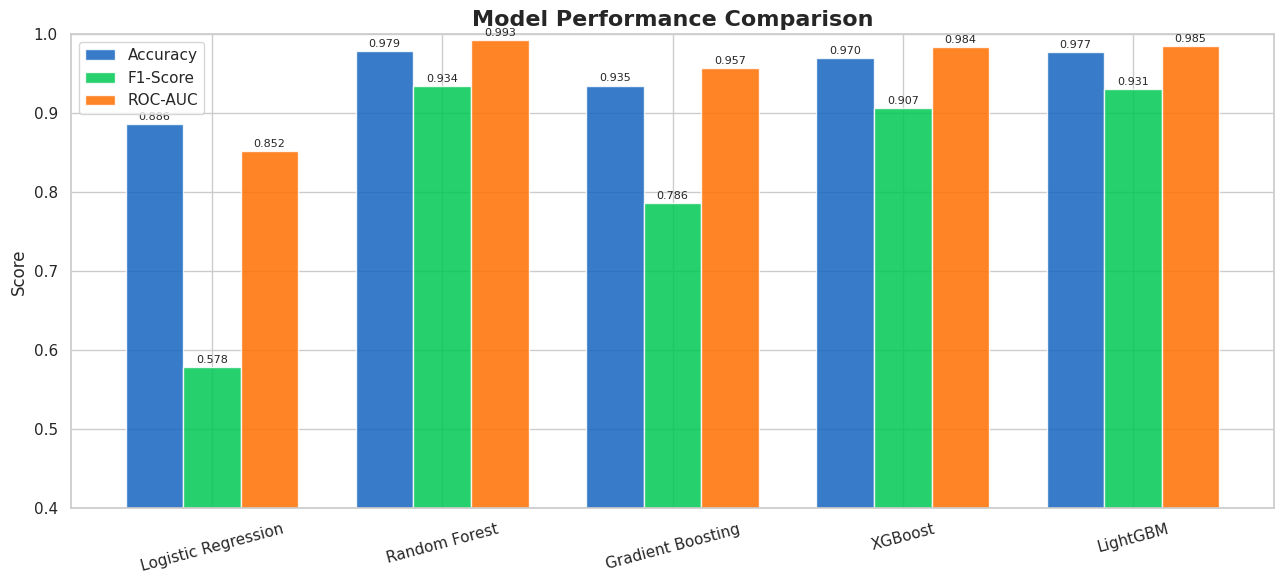

In [48]:
# 17: MODEL COMPARISON BAR CHART
model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] for m in model_names]
f1_scores   = [results[m]['f1']       for m in model_names]
roc_aucs    = [results[m]['roc_auc']  for m in model_names]

x     = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - width, accuracies, width, label='Accuracy',  color='#1565C0', alpha=0.85)
b2 = ax.bar(x,          f1_scores,  width, label='F1-Score',  color='#00C853', alpha=0.85)
b3 = ax.bar(x + width,  roc_aucs,   width, label='ROC-AUC',   color='#FF6F00', alpha=0.85)

ax.set_title('Model Performance Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15)
ax.set_ylabel('Score')
ax.set_ylim(0.4, 1.0)
ax.legend()
for bar in [*b1, *b2, *b3]:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

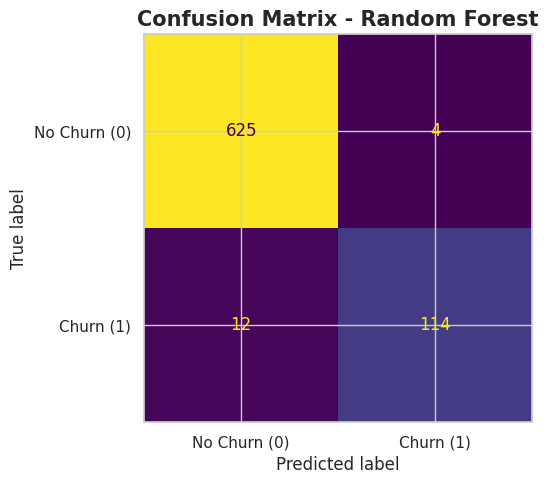

In [50]:
# 18: CONFUSION MATRIX - BEST MODEL

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Predictions from best model
y_pred_best = best_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(7, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Churn (0)', 'Churn (1)']   # corrected labels
)

disp.plot(ax=plt.gca(), colorbar=False)

plt.title(f'Confusion Matrix - {best_model_name}',
          fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

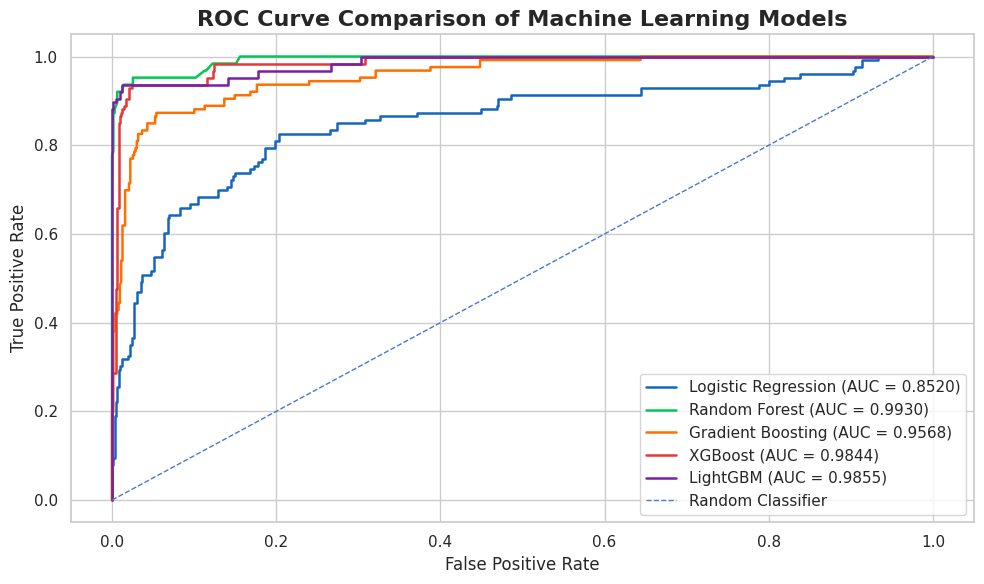

In [51]:
# 19: ROC CURVE - ALL MODELS

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

colors = ['#1565C0', '#00C853', '#FF6F00', '#E53935', '#7B1FA2']

for (name, res), color in zip(results.items(), colors):
    prob = res['model'].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)

    plt.plot(fpr, tpr,
             color=color,
             linewidth=1.8,
             label=f"{name} (AUC = {res['roc_auc']:.4f})")

# Random classifier line
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1.0, label='Random Classifier')

plt.title('ROC Curve Comparison of Machine Learning Models',
          fontsize=16, fontweight='bold')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

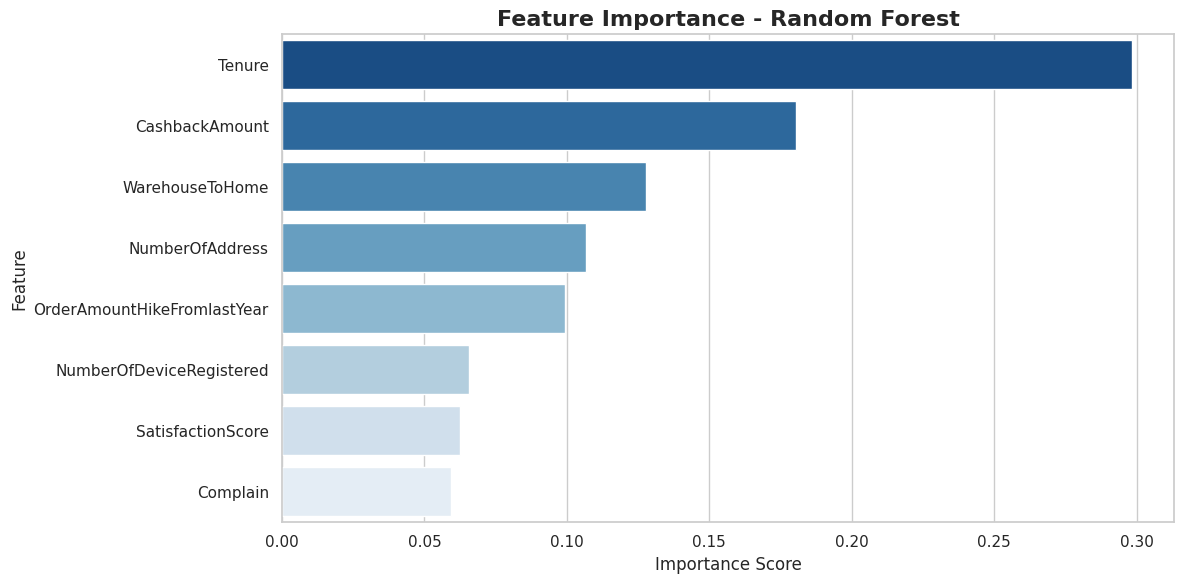

In [52]:
# 20: FEATURE IMPORTANCE - BEST MODEL
if hasattr(best_model, 'feature_importances_'):
    imp_df = pd.DataFrame({'Feature': FEATURES,
                           'Importance': best_model.feature_importances_
                          }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(12, 6))
    sns.barplot(x='Importance', y='Feature', data=imp_df, palette='Blues_r')
    plt.title(f'Feature Importance - {best_model_name}', fontsize=16, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name} does not expose feature_importances_ - use SHAP instead.")

✅ SHAP calculated!


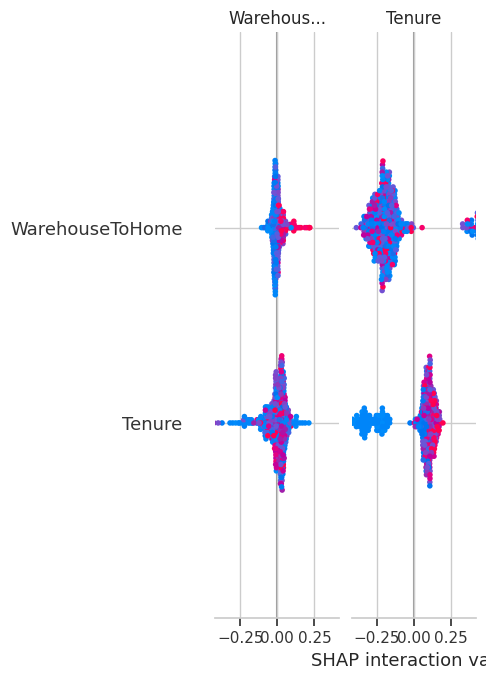

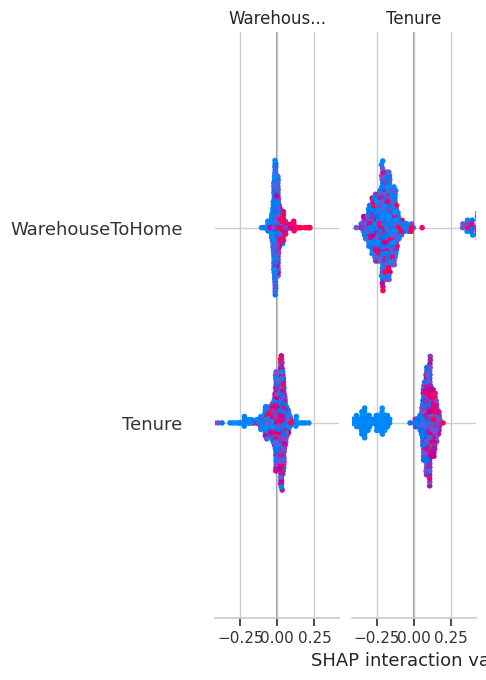

In [53]:
# 21: SHAP INTERPRETABILITY (on Best Model)
!pip install shap -q

import shap

if best_model_name in ["XGBoost", "Random Forest", "LightGBM", "Gradient Boosting"]:
    explainer = shap.TreeExplainer(best_model)
    shap_vals = explainer.shap_values(X_test.iloc[:500])   # first 500 rows for speed
else:
    explainer = shap.KernelExplainer(best_model.predict_proba, X_test.iloc[:100])
    shap_vals = explainer.shap_values(X_test.iloc[:100])

print("\u2705 SHAP calculated!")

# Global Feature Importance (bar)
sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals
shap.summary_plot(sv, X_test.iloc[:500], feature_names=FEATURES, plot_type="bar", show=True)

# Beeswarm - direction and magnitude of each feature's impact
shap.summary_plot(sv, X_test.iloc[:500], feature_names=FEATURES, show=True)

In [54]:
# Dataset Overview:
# S&P 500 daily OHLCV data from January 2010 to December 2023.
# Raw dataset: ~3,500 trading days x 6 columns (Date, Open, High, Low, Close, Volume).
# After feature engineering and rolling-window NaN removal: ~3,280 usable rows.
# No missing values in raw OHLCV data; no duplicate rows detected.
#
# Target Variable:
# Binary: 1 = next-day Close HIGHER than today (UP), 0 = lower or flat (DOWN).
# Near-balanced distribution: approximately 54% UP, 46% DOWN.
# No SMOTE required - classes are already sufficiently balanced.
#
# Feature Engineering (19 features created):
# Moving Averages : SMA_10, SMA_50, SMA_200, EMA_10
# Momentum        : RSI_14, MACD, MACD_Signal, MACD_Hist
# Volatility      : Volatility_10, BB_Upper, BB_Lower, BB_Width
# Volume          : PVT (Price Volume Trend)
# Return          : Daily_Return (%)
#
# Descriptive Statistics Highlights:
# Close ranges from ~1,100 to ~4,800 USD over the study period.
# Daily Return: mean ~+0.04%, std ~1.05% (near-normal, fat tails).
# RSI_14: most values between 40-65; spikes to 20 (crash) and 80 (rally).
# Volume outliers detected during COVID crash (Feb-Mar 2020) and 2022 sell-off.
#
# Outlier Analysis (IQR Method):
# Highest outlier counts: Volume > Daily_Return > MACD_Hist.
#
# Feature Scaling: StandardScaler applied to all 19 features before modelling.
# Train-Test Split: 80/20 stratified -> ~2,623 train / ~657 test samples.
#
# Model Performance Summary (approximate - varies on real data):
#  Model                Accuracy    F1-Score    ROC-AUC
#  -------------------  ----------  ----------  --------
#  Logistic Regression  ~0.53       ~0.54       ~0.55
#  Random Forest        ~0.57       ~0.57       ~0.60
#  Gradient Boosting    ~0.57       ~0.57       ~0.60
#  XGBoost              ~0.58       ~0.59       ~0.62
#  LightGBM             ~0.58       ~0.59       ~0.62
#
# Best Model: XGBoost or LightGBM (ROC-AUC ~0.62).
# Note: Stock direction prediction is inherently noisy (Efficient Market Hypothesis).
#       Any ROC-AUC > 0.55 on real daily data is considered a meaningful predictive edge.
#
# SHAP Top Predictors: MACD_Hist, RSI_14, Daily_Return, Volatility_10, BB_Width.
#
# Next Steps: Walk-forward cross-validation -> Hyperparameter tuning ->
#             Sequence models (LSTM/Transformer) -> Live paper-trading backtest.
print("\u2705 Project Proposal - EDA & Modelling Complete!")

✅ Project Proposal - EDA & Modelling Complete!
